# EDA - Analisis Exploratorio de datos: RRHH

**repaso de todo lo aprendido en el curso**: lectura de ficheros, pandas (exploracion y limpieza) y numpy (operaciones matematicas), y visualizacion con matplotlib, seaborn y plotly.


## StoryTelling: Contexto

Formáis parte del equipo de análisis de datos del departamento de **Recursos Humanos** de una empresa.

Nos han exportado un extracto de la base de datos de personal (`data/empleados_rrhh.csv`) y dirección os pide un **informe exploratorio** para entender cómo está compuesta la plantilla antes de tomar decisiones (revisión salarial, plan de teletrabajo, etc.).

Como en cualquier dataset real, **los datos no llegan limpios**: habrá nulos, departamentos escritos de formas distintas y filas duplicadas. Vamos a seguir el proceso típico de un EDA:

1. Carga de datos
2. Primera exploración
3. Calidad de datos (nulos, duplicados, inconsistencias)
4. Limpieza
5. Análisis univariante (una variable) + visualización
6. Análisis bivariante (relación entre variables) + visualización
7. Correlación entre variables numéricas
8. Un gráfico interactivo con Plotly
9. Conclusiones

## 0.importacion de librerias y configuraciones iniciales

- revisar que nuestro entorno de desarrollo esta activado y que tenemos todas las librerias instaladas

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests as rq

sns.set_theme(style='whitegrid')

## 1.carga de datos

empezamos siempre igual, los datos o bien vienen de base de datos; API; o de un fichero.

In [143]:
df = pd.read_csv('./data/empleados_rrhh.csv')
df.head() # saca los primeros 5 registros

,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
0,79,Beatriz Rubio,Marketing,Hombre,42.0,11.0,32852.78,6.0,18,False
1,151,Ana López,marketing,Hombre,47.0,11.0,36555.44,9.0,1,True
2,172,Teresa Ruiz,ventas,Mujer,52.0,14.0,38518.68,6.0,17,True
3,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
4,191,Silvia Gómez,VENTAS,Mujer,50.0,14.0,37651.75,5.0,17,True


## 1.1.insercion de nuevos datos desde n8n:

antes de empezar a limpiar y analizar datos vamos a simular una automatizacion de un ERP de RRHH que envia datos para completar el excel que me pasan.



In [144]:
URL_insert_data = "https://miriam.n8ncamp.com/webhook/nuevos-empleados"

response1 = rq.get(URL_insert_data, timeout=10)
df_nuevos = pd.DataFrame(response1.json())

df = pd.concat([df, df_nuevos], ignore_index=True)
print(f'empleados nuevos incorporados desde n8n {len(df_nuevos)}')
print('dimension del nuevo dataframe', df.shape)
df.tail()

empleados nuevos incorporados desde n8n 550
dimension del nuevo dataframe (780, 10)


,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
775,9545,Elisa Flores,Finanzas,Mujer,51.0,1.0,34625.26,7.0,3,False
776,9546,Asunción Reyes,Finanzas,Mujer,44.0,1.0,37855.75,6.0,4,False
777,9547,Silvia Ortiz,Marketing,Mujer,33.0,0.0,35623.94,4.0,4,False
778,9548,Mohamed Blanco,IT,Hombre,66.0,0.0,30848.28,6.0,6,True
779,9549,José Santiago,RRHH,Hombre,31.0,2.0,38658.91,6.0,9,False


## 2.primera exploracion

antes de tocar nada, necesitamos entender que tenemos entre manos:
    - cuantas filas 
    - cuantas columnas
    - tipos de datos
    - donde estan los valores numericos

In [145]:
print('dimensiones en filas y columnas', df.shape) # da informacion del numero de filas y columnas
df.info() # resumen de la estructura de un DataFrame.

dimensiones en filas y columnas (780, 10)
<class 'pandas.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_empleado       780 non-null    int64  
 1   nombre            780 non-null    str    
 2   departamento      780 non-null    str    
 3   genero            780 non-null    str    
 4   edad              769 non-null    float64
 5   antiguedad_anios  772 non-null    float64
 6   salario_anual     689 non-null    float64
 7   satisfaccion      774 non-null    float64
 8   horas_extra_mes   780 non-null    int64  
 9   teletrabajo       780 non-null    bool   
dtypes: bool(1), float64(4), int64(2), str(3)
memory usage: 55.7 KB


fijaos en dos cosas df.info():
    - hay columnas con menos valores no nulos que filas totales -> tenemos valores nulos
    - comprobar que no hay id de empleados duplicados

### resumen estadistico: todas las estadisticas tipicas: media, mediana, min, max, cuartiles, etc...

In [146]:
df.describe().round(2) # resumen estadistico de el dataframe

,id_empleado,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes
count,780.00,769.00,772.00,689.00,774.00,780.00
mean,6572.64,49.47,2.95,33224.85,5.07,7.69
std,4183.07,15.75,3.93,11284.58,2.67,4.95
min,1.00,22.00,0.00,18532.34,0.00,0.00
25%,187.75,36.00,1.00,28864.87,3.00,3.00
50%,9159.50,49.00,2.00,32401.25,6.00,7.00
75%,9354.25,61.00,2.00,36341.52,7.00,12.00
max,9549.00,81.00,15.00,235000.00,9.00,20.00


## 3. calidad de los datos

antes de limpiar hay que **detectar** los problemas. vamos a revisar la cantidad de nulos, duplicados

In [147]:
# 3.1. nulos por columna

df.isnull().sum()

id_empleado          0
nombre               0
departamento         0
genero               0
edad                11
antiguedad_anios     8
salario_anual       91
satisfaccion         6
horas_extra_mes      0
teletrabajo          0
dtype: int64

In [148]:
# 3.2. filas duplicadas: mismo empleado registrado mas de una vez.

print('filas duplicadas', df.duplicated().sum())

filas duplicadas 10


In [149]:
# 3.3. cuantos valores distintos tiene departamento? deberia haber solo 5

df['departamento'].value_counts()

departamento
Ventas        87
IT            69
Finanzas      54
RRHH          51
Marketing     50
it            44
MARKETING     39
RRHH          38
It            36
VENTAS        34
 Ventas       34
marketing     33
ventas        31
Rrhh          31
rrhh          30
 IT           27
FINANZAS      25
 Marketing    25
Finanzas      23
finanzas      19
Name: count, dtype: int64

como sospechabamos: el mismo departamento aparece escrito de varias formas. (IT,it). esto es muy habitual cuando los datos se han introducido o vienen de sistemas distintos.

### 4.limpieza de datos

## 4.1. normalizar la columna departamento. quitar espacios en blanco, mayusculas y minusculas

In [150]:
df['departamento'] = df['departamento'].str.strip().str.upper()
print(df['departamento'])

# diccionario de traduccion con el nombre bonito

nombres_departamento = {
    'IT': 'IT',
    'VENTAS': 'Ventas',
    'MARKETING': 'Marketing',
    'RRHH':'RRHH',
    'FINANZAS': 'Finanzas'
}

df['departamento'] = df['departamento'].replace(nombres_departamento)
df['departamento'].value_counts()

0      MARKETING
1      MARKETING
2         VENTAS
3           RRHH
4         VENTAS
         ...    
775     FINANZAS
776     FINANZAS
777    MARKETING
778           IT
779         RRHH
Name: departamento, Length: 780, dtype: str


departamento
Ventas       186
IT           176
RRHH         150
Marketing    147
Finanzas     121
Name: count, dtype: int64

## 4.2. eliminar duplicados


In [151]:
df = df.drop_duplicates()
print('filas tras eliminar duplicados', len(df))
print('duplicado restante', df.duplicated().sum())

filas tras eliminar duplicados 770
duplicado restante 0


## 4.3. tratar los valores nulos

no todos los valores nulos se tratan igual, depende de la columna y tipo de dato.

    - edad, antigüedad_anios, satisfaccion -> los rellenamos con la mediana (es la forma mas robusta de estimar un valor "tipico" sin que nos afecte a los extremos).
    - el salario_anual -> en lugar de usar la mediana global, usamos la mediana pero solo del departamento. usamos group by para agrupar por departamento.
    - nombre, apellidos son susceptibles de eliminarse.

In [152]:
# edad, antigüedad y satisfaccion -> mediana global

for columna in ['edad', 'antiguedad_anios', 'satisfaccion']:
    mediana = df[columna].median()
    df[columna] = df[columna].fillna(mediana) # fillna rellena los que no tienen numero (na=no a number), fill(rellena todo sea nulo o no)

# salario -> mediana de todo el departamento
df['salario_anual'] = df['salario_anual'].fillna(
    df.groupby('departamento')['salario_anual'].transform('median')
)

# si tuviesemos que eliminar un registro con valor nulo
# df.dropna() # eliminas todos los nulos

# si quisiera eliminar todo el registro en base a una columna ej-> nombre
# df.dorpna(subset=['nombre', 'apellidos'])

# si quiero eliminar directamente el campo de df
# df.dropna(subset=['nombre'], inplace=True)

# comprobacion final: no deberia quedar ningun null

df.isnull().sum()

id_empleado         0
nombre              0
departamento        0
genero              0
edad                0
antiguedad_anios    0
salario_anual       0
satisfaccion        0
horas_extra_mes     0
teletrabajo         0
dtype: int64

### 5.analisis univariante

## 5.1. empleados por departamento

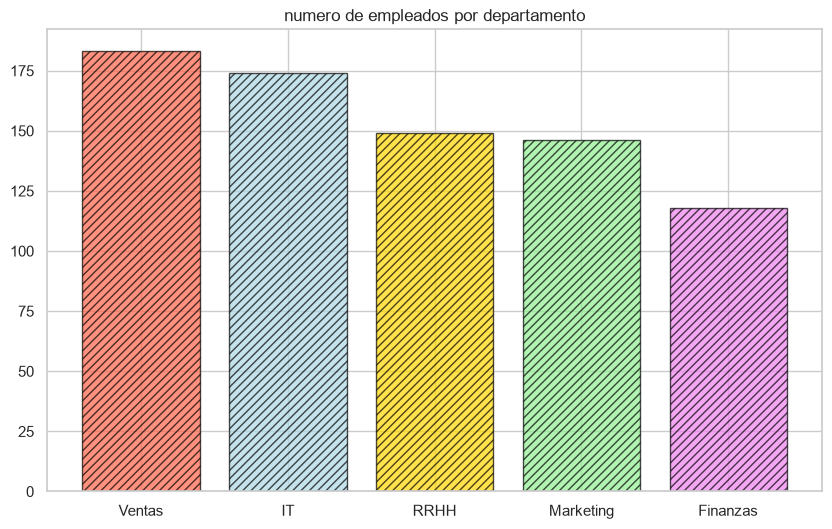

In [153]:
conteo_dpto = df['departamento'].value_counts().reset_index() # reset_index: recuperar los indices
conteo_dpto.columns = ['departamento', 'cantidad']

# matplotlib
plt.figure(figsize=(10,6))
plt.title('numero de empleados por departamento')
plt.bar(conteo_dpto['departamento'], conteo_dpto['cantidad'], alpha=0.7, edgecolor='black', color=['tomato', 'lightblue', 'gold', 'lightgreen', 'violet'], hatch='////')
plt.xlabel='departamento'
plt.ylabel='numero de empleados'
plt.show()

## 5.2. distribucion de la edad

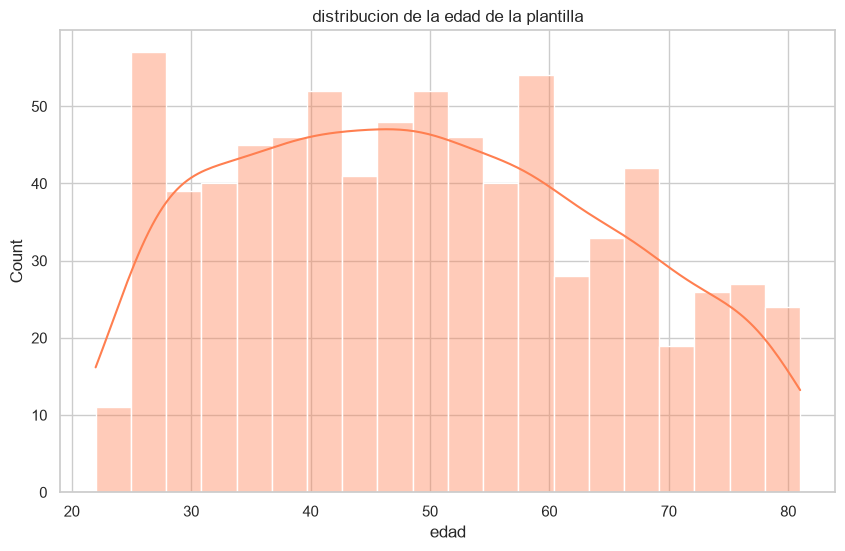

In [154]:
plt.figure(figsize=(10,6))
plt.title('distribucion de la edad de la plantilla')
sns.histplot(
    data=df,
    x='edad',
    kde=True,
    color='coral',
    alpha=0.4,
    bins=20
)



plt.show()

## 5.3. distribucion del salario

vamos a usar boxplot porque nos permite ver la mediana, rango intercualtilico y valores atipicos

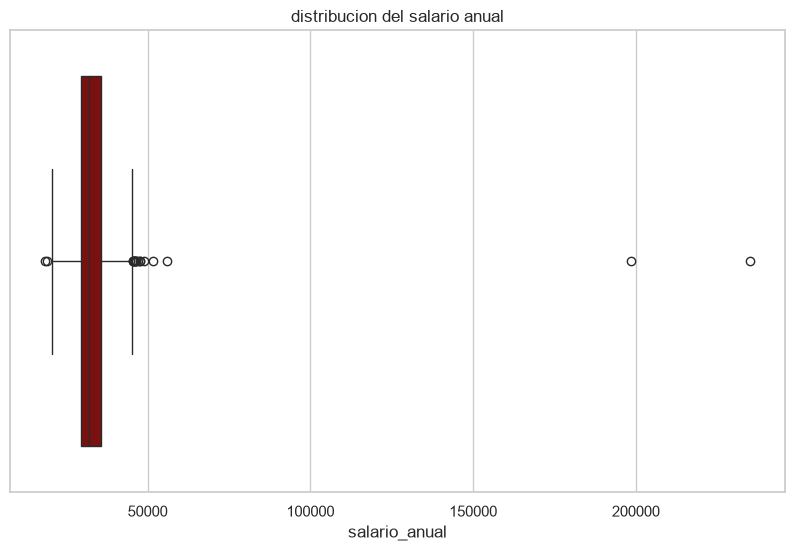

In [155]:
plt.figure(figsize=(10,6))
plt.title('distribucion del salario anual')
sns.boxplot(
    data=df,
    x='salario_anual',
    color='darkred'
)



plt.show()

In [156]:
# quienes son esos outliers que se salen de rango?
df[df['salario_anual'] > 100000] [['nombre', 'departamento', 'antiguedad_anios', 'salario_anual']]

# salario medio:
df['salario_anual'].mean().round(2)

np.float64(33114.48)

## 5.4. reparto por genero

genero
Mujer      288
Hombre     262
Hombre     118
Mujer      102
Name: count, dtype: int64


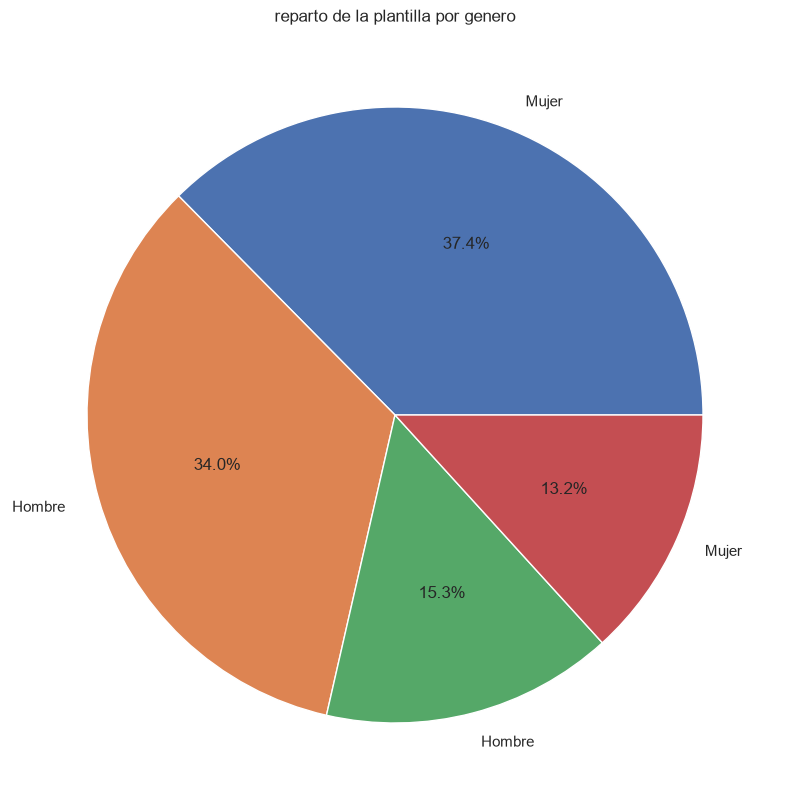

In [157]:
conteo_genero = df['genero'].value_counts()
print(conteo_genero)

plt.figure(figsize=(10,10))
plt.title('reparto de la plantilla por genero')
plt.pie(
    conteo_genero,
    labels=conteo_genero.index,
    autopct='%1.1f%%'
)

plt.show()

### 6.analisis bivariante 

vamos a cruzar variables entre si para establecer relaciones.

## 6.1.salario medio por departamento.

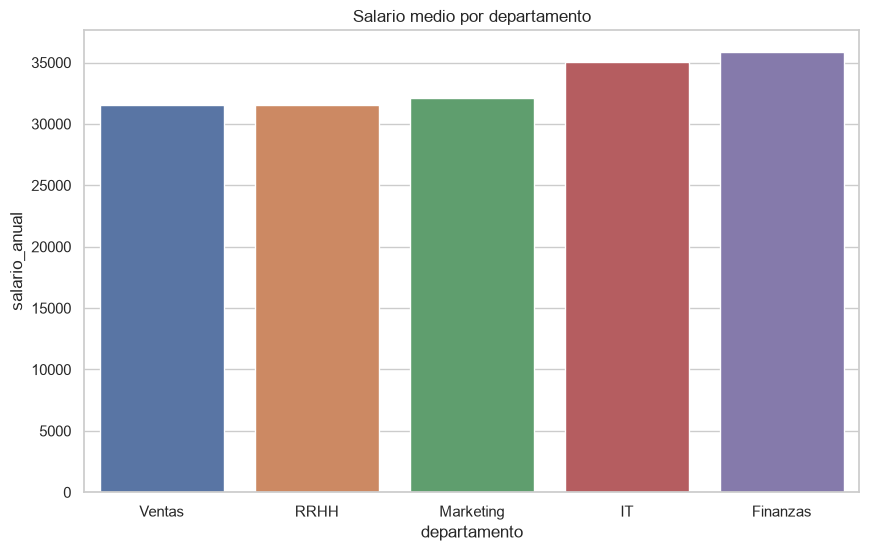

In [158]:
#creacion dataframe nuevo
salario_medio_dpto = (
    df.groupby('departamento')['salario_anual']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('salario_anual', ascending=True)
)

salario_medio_dpto

# salario_medio_dpto los dataFrames no necesitan print
plt.figure(figsize=(10,6))
plt.title('Salario medio por departamento')
sns.barplot(
data=salario_medio_dpto, 
x="departamento", 
y="salario_anual", 
hue="departamento"
)
plt.show()



## 6.2.relacion entre edad y salario

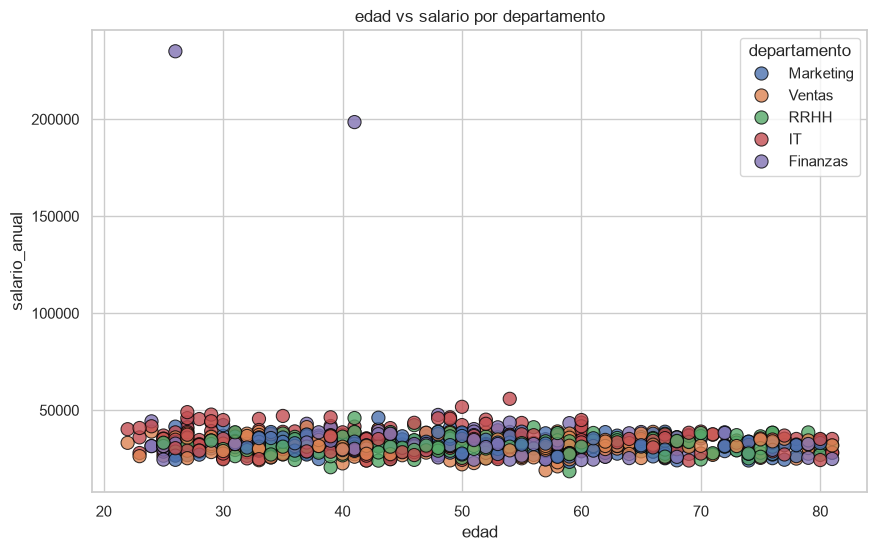

In [159]:
plt.figure(figsize=(10,6))
plt.title('edad vs salario por departamento')
sns.scatterplot(
    data=df,
    x='edad',
    y='salario_anual',
    hue='departamento',
    s=90,
    alpha=0.8,
    edgecolor='black')
plt.show()

## 6.3.influye el teletrabajo en la satisfaccion de los trabajadores?

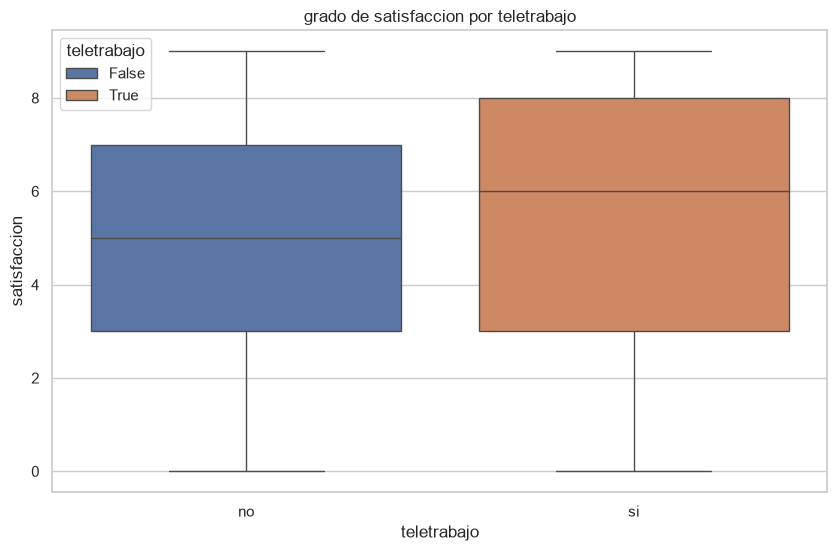

In [160]:
plt.figure(figsize=(10,6))
plt.title('grado de satisfaccion por teletrabajo')
sns.boxplot(
    data=df,
    x='teletrabajo',
    y='satisfaccion',
    hue='teletrabajo'
)
plt.xticks([0,1],['no', 'si'])
plt.show()

### 7.correlacion entre variables numericas

la matriz de correlacion nos dice de un vistazo que variables numericas se mueven juntas

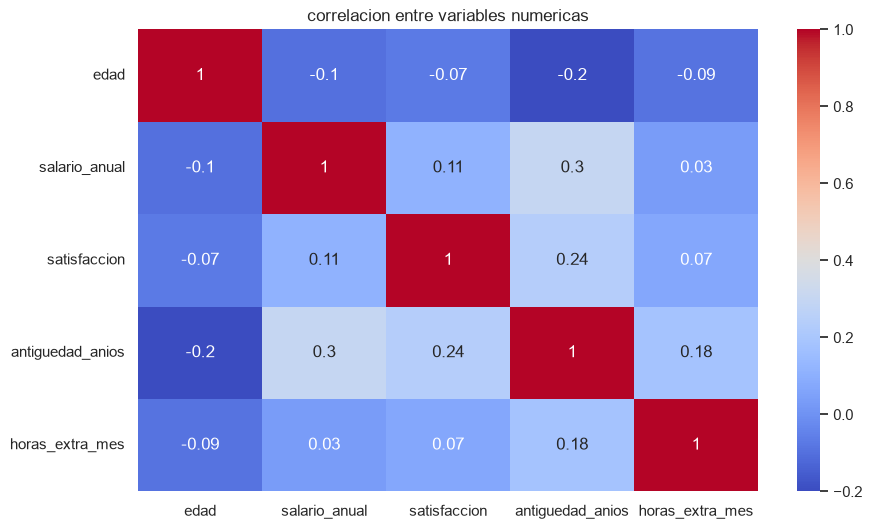

In [161]:
columnas_numericas = ['edad', 'salario_anual', 'satisfaccion', 'antiguedad_anios', 'horas_extra_mes']

matriz_correlacion = df[columnas_numericas].corr().round(2)
plt.figure(figsize=(10,6))
plt.title('correlacion entre variables numericas')
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm'
)
plt.show()

### 8.grafico interactivo con plotly

como ya sabeis con plotly podemos crear el mismo tipo de graficos pero interactivos

In [162]:
fig = px.box(
    df,
    x="departamento",
    y="salario_anual",
    color='departamento',
    points="all",
    title="Distribución del salario por departamento",
    labels={'departamento': 'Departamento', 'salario_anual': 'Salario Anual (€)'}
)

fig.show()

---
## Resumen de funciones utilizadas

| Función / Sintaxis | ¿Para qué sirve? |
|---|---|
| `pd.read_csv()` | Cargar los datos |
| `df.shape` / `df.info()` / `df.describe()` | Primera exploración |
| `df.isnull().sum()` | Contar nulos por columna |
| `df.duplicated()` / `df.drop_duplicates()` | Detectar y eliminar duplicados |
| `df[col].value_counts()` | Distribución de una columna categórica |
| `.str.strip()` / `.str.upper()` / `.replace()` | Normalizar texto |
| `df[col].fillna(valor)` | Rellenar nulos |
| `df.groupby(col).transform()` | Rellenar nulos con un valor por grupo |
| `df.astype()` | Cambiar el tipo de una columna |
| `sns.barplot` / `sns.histplot` / `sns.boxplot` / `sns.scatterplot` / `sns.heatmap` | Visualización estática (seaborn) |
| `plt.pie` | Gráfico de sectores (matplotlib) |
| `df[cols].corr()` | Matriz de correlación |
| `px.box` | Gráfico interactivo (plotly) |
| `requests.get()` / `requests.post()` | Llamar a un webhook de n8n (traer datos / enviar el informe) |

### 9.conclusiones

resumen de todo lo que hemos auditado:
    
    - el departamento con concentracion de empleados es IT y despues ventas.

    - el departamento que tiene el salario medio mas alto es el de finanzas y luego IT.
    
    - el salario medio en esta empresa es de 37000€.
    
    - el numero de hombres y mujeres esta bastante compensado cercano al 50%.
    
    - tenemos una concentracion de trabajadores en edad media de entre 37-47 años.
    
    - el grado de satisfaccion no es mucho mayor por el hecho de teletrabajar.
    
    - hay dos salarios muy por encima del resto(outliers) que convendria revisar con el negocio.
    
    - unos de los departamentos mas pequeños en cuanto a numero de empleados condensa la mayoria la mayoria de los salarios mas altos.
    
    - la antigüedad y el salario estan ligeramente relacionados a mayor sueldo.
    
    - el dataset original tenia inconsistencias, datos nulos, formatos equivocados que se han tenido que limpiar.
    

### 10.enviar el informe automatizado

In [ ]:
conclusiones = """El departamento con concentracion de empleados en IT y segundo Ventas.\nEl departamento que tiene el salario medio más alto es el de finanzas y luego IT.\nEl salario medio en esta empresa esta en 37000 €\nEl numero de hombres y mujeres esta bastante compensado cercano a 50%\nTenemos un concentración de trabajadores en edad media de entre 37 - 47 años\nEl grado de satisfación no es mucho mayor por el hecho de teletrabajar.\nHay dos salarios muy por encima del resto (outliers) que convendría revisar con negocio.\nUnos de los departamentos más pequeños en cuanto numero de empleados condensa la mayoría de los salarios mas altos.\nLa antigüedad y el salario están ligeramente relacionados a mayor mayor sueldo.\nEl dataset original tenia inconsistencias, datos nulos, formato equivocados que se han tenido que limpiar\n
"""

resumen = {
    "fecha_informe": pd.Timestamp.today().strftime('%d-%m-%Y %H:%M'),
    "total_empleados": len(df),
    "salario_medio": float(df['salario_anual'].mean().round(2)),
    "departamento_mas_grande": df['departamento'].value_counts().idxmax(),
    "numero_empleados_departamento_mas_grande":  int(df['departamento'].value_counts().max()),
    "empleados_hacen_teletrabajo": f"{int(df['teletrabajo'].mean() * 100)}%",
    "conclusiones": conclusiones
}

URL_informe = "https://miriam.n8ncamp.com/webhook/informe-rrhh"

response = rq.post(URL_informe, json=resumen, timeout=10)
print(response.json())

    

{'status': 'OK', 'mesagge': 'el resumen se ha enviado correctamente'}
